# ANOVA (Análisis de varianza)

Comparación de medias entre grupos usando la **F**.

In [1]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt

### Ejemplo teórico

In [2]:
def calcular_componentes_anova(grupos):
    # Número de grupos
    k = len(grupos)
    # Total de observaciones
    N = sum(len(g) for g in grupos)
    # Media general
    media_global = np.mean(np.concatenate(grupos))
    
    # Suma de cuadrados entre grupos
    ss_entre = sum(len(g) * (np.mean(g) - media_global)**2 for g in grupos)
    df_entre = k - 1
    ms_entre = ss_entre / df_entre
    
    # Suma de cuadrados dentro de grupos
    ss_dentro = sum(((g - np.mean(g))**2).sum() for g in grupos)
    df_dentro = N - k
    ms_dentro = ss_dentro / df_dentro
    
    # Estadístico F
    F = ms_entre / ms_dentro

    # p-valor
    p_value = st.f.sf(F, df_entre, df_dentro)
    
    return F, ms_entre, ms_dentro, df_entre, df_dentro, p_value


In [3]:
np.random.seed(42)
grupoA = np.random.normal(70.5, 5, 20)
grupoB = np.random.normal(71, 5, 20)
grupoC = np.random.normal(76, 5, 20)

F, num, den, df1, df2, p  = calcular_componentes_anova([grupoA, grupoB, grupoC])

print(f"MS entre grupos     = {num:.4f}")
print(f"MS dentro de grupos = {den:.4f}")
print(f"                  F = {F:.4f}")
print(f"p-valor:{p:.6f}\n")

MS entre grupos     = 257.0754
MS dentro de grupos = 21.1045
                  F = 12.1810
p-valor:0.000039



In [4]:
f_stat, p_anova = st.f_oneway(grupoA, grupoB, grupoC)
print(f"F: {f_stat:.4f}, p-valor: {p_anova:.6f}")

F: 12.1810, p-valor: 0.000039


### Ejemplo. ANOVA para diferencia de medias entre grupos

Se llevó a cabo un experimento donde se compararon tres tipos de motores, A, B y C.
Se midió el rendimiento de combustible en litros cada 100 km.
Se realizaron 50 mediciones con el motor tipo A, 75 con el motor de tipo B y 60 con el motor de tipo C.
La gasolina utilizada y las demás condiciones se mantuvieron constantes.

El consumo promedio fue de aproximadamente 5,6 litros / 100 km.,  6,5 litros / 100 km y  6,6 litros / 100 km, y las desviaciones estándar 1,07 l. / 100 km., 0,9 l. / 100 km. y 1,3 l. / 100 km. para los motores A, B y C respectivamente.

Calcular un ANOVA de un factor para determinar si existen diferencias significativas en el consumo promedio de combustible entre los tres tipos de motores.

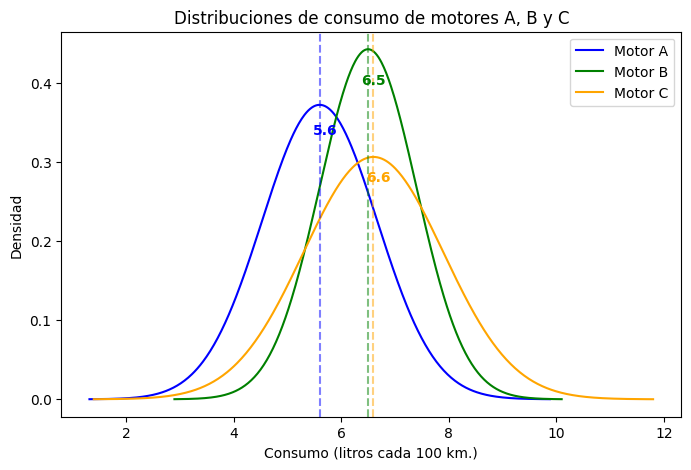

In [5]:
# Variables para los tres motores
media1, sigma1, n1 = 5.6, 1.07, 50  # Motor A
media2, sigma2, n2 = 6.5, 0.9, 75  # Motor B
media3, sigma3, n3 = 6.6, 1.3, 60  # Motor C

# Valores para las distribuciones
x1 = np.linspace(media1 - 4*sigma1, media1 + 4*sigma1, 500)
x2 = np.linspace(media2 - 4*sigma2, media2 + 4*sigma2, 500)
x3 = np.linspace(media3 - 4*sigma3, media3 + 4*sigma3, 500)

# Distribuciones normales
y1 = st.norm.pdf(x1, media1, sigma1)
y2 = st.norm.pdf(x2, media2, sigma2)
y3 = st.norm.pdf(x3, media3, sigma3)

# Graficar PDFs
plt.figure(figsize=(8,5))
plt.plot(x1, y1, label='Motor A', color='blue')
plt.plot(x2, y2, label='Motor B', color='green')
plt.plot(x3, y3, label='Motor C', color='orange')

# Líneas verticales para las medias
plt.axvline(media1, color='blue', linestyle='--', alpha=0.5)
plt.axvline(media2, color='green', linestyle='--', alpha=0.5)
plt.axvline(media3, color='orange', linestyle='--', alpha=0.5)

# Etiquetas de medias
plt.text(media1+0.1, max(y1)*0.9, f'{media1}', color='blue', ha='center', fontweight='bold')
plt.text(media2+0.1, max(y2)*0.9, f'{media2}', color='green', ha='center', fontweight='bold')
plt.text(media3+0.1, max(y3)*0.9, f'{media3}', color='orange', ha='center', fontweight='bold')

plt.xlabel("Consumo (litros cada 100 km.)")
plt.ylabel("Densidad")
plt.title("Distribuciones de consumo de motores A, B y C")
plt.legend()
plt.show()

In [6]:
# Generar datos de cada motor
motor_A = np.random.normal(media1, sigma1, n1)
motor_B = np.random.normal(media2, sigma2, n2)
motor_C = np.random.normal(media3, sigma3, n3)

f_stat, p_anova = st.f_oneway(motor_A, motor_B, motor_C)
print(f"F: {f_stat:.2f}, p-valor: {p_anova:.6f}")

if p_anova < 0.05:
    print("Rechazamos H0: al menos una media es diferente.")
else:
    print("No hay evidencia suficiente para rechazar H0.")


F: 17.46, p-valor: 0.000000
Rechazamos H0: al menos una media es diferente.


#### Test post hoc

Cuando ANOVA da una diferencia significativa, puedo correr una prueba post hoc para saber qué grupos son diferentes.

In [7]:
# Tukey HSD (Honest Significant Difference)

from statsmodels.stats.multicomp import pairwise_tukeyhsd

valores=np.concatenate([motor_A, motor_B, motor_C])
grupos=['A']*len(motor_A) + ['B']*len(motor_B) + ['C']*len(motor_C)

tukey = pairwise_tukeyhsd(valores, grupos, alpha=0.05)

print(tukey.summary())

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     A      B   1.0044    0.0  0.5376 1.4713   True
     A      C   1.1147    0.0  0.6251 1.6044   True
     B      C   0.1103 0.8265 -0.3326 0.5532  False
---------------------------------------------------
